In [4]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns



dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])




In [5]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

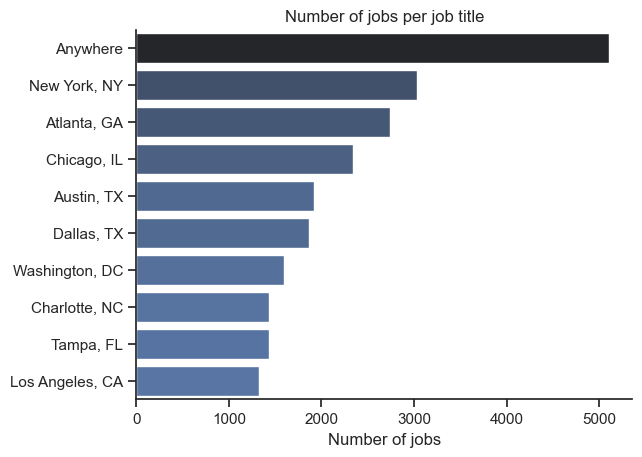

In [23]:
df_usa = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]
df_plot =df_usa['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count',y='job_location',hue='count',palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of jobs per job title')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()

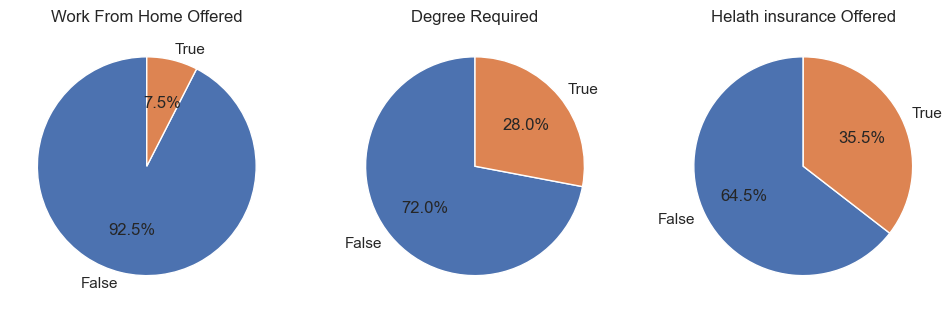

In [29]:

dict_column = {
  'job_work_from_home':'Work From Home Offered',
  'job_no_degree_mention':'Degree Required',
  'job_health_insurance':'Helath insurance Offered',
}

fig , ax = plt.subplots(1,3)
fig.set_size_inches(12,5)

for i , (column,title) in enumerate(dict_column.items()):
  ax[i].pie(df_usa[column].value_counts(), labels=['False','True'],autopct='%1.1f%%',startangle=90)
  ax[i].set_title(title)
  

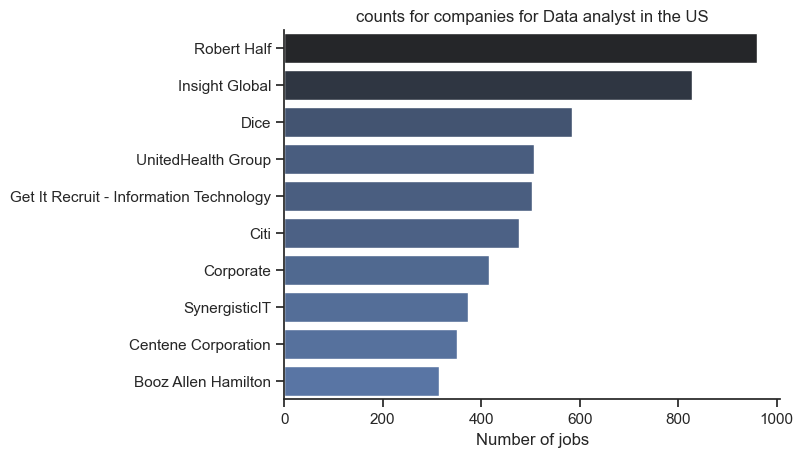

In [30]:
df_plot =df_usa['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count',y='company_name',hue='count',palette='dark:b_r', legend=False)
sns.despine()
plt.title('counts for companies for Data analyst in the US')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()